In [64]:
from lib_3d_OT.utils import *
import scanpy as sc
import numpy as np
import pandas as pd
import torch
from lib_3d_OT.single_modialty import *
from lib_3d_OT.multi_modialty import *
import torch.optim as optim
import warnings
warnings.filterwarnings("ignore")

In [2]:
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

In [39]:
adata=sc.read_h5ad('/home/dbj/lib_3d_OT/revise/scGPT/674-embedding.h5ad')
# sc.pp.normalize_total(adata, inplace=True)
# sc.pp.log1p(adata)
# sc.pp.scale(adata, zero_center=False, max_value=10)
adata.obsm['feat']=adata.X

In [40]:
set_seed(7)
graph = prepare_data(adata, location="spatial", nb_neighbors=16).to(device)
input_dim1 = graph.express.shape[-1]
model = extractMODEL(args=None,input_dim=input_dim1)
optimizer = optim.Adam(model.parameters(), lr=0.001)
best_model, min_loss = train_graph_extractor(graph, model, optimizer, device,epochs=1150)

Epoch 1150/1150, Loss: 0.000062, Min Loss: 0.000062

In [41]:
with torch.no_grad(): 
    model.eval()
    z= model.get_features(graph)
    decoded_features = model.decode(z)
    gene_expression_matrix = decoded_features.cpu().squeeze(0).detach().numpy()
adata.obsm['3d-OT']=gene_expression_matrix

In [49]:
clustering(adata, n_clusters=7, radius=50, key='3d-OT', method='mclust', refinement=True,random=2023,n_comp=20)

Using 3d-OT representation for clustering...
fitting ...
  |======================================================================| 100%


In [50]:
sc.settings.figdir = '/home/dbj/lib_3d_OT/revise/scGPT/'

In [51]:
from sklearn.metrics import adjusted_rand_score,normalized_mutual_info_score
ARI = adjusted_rand_score(adata.obs['truth'], adata.obs['3d-OT'])
NMI = normalized_mutual_info_score(adata.obs['truth'], adata.obs['3d-OT'])
ARI,NMI

(0.3165738482126135, 0.44350667342302896)

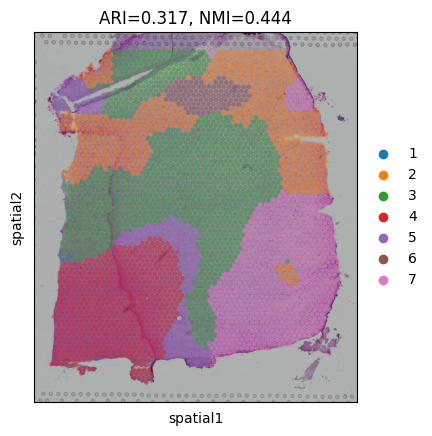

In [52]:
sc.pl.spatial(adata, color='3d-OT', img_key='hires',title='ARI=0.317, NMI=0.444', alpha=0.5, size=1.3,save='scGPT6743d-OT.png')

In [53]:
adata=sc.read_h5ad('/home/dbj/lib_3d_OT/revise/scGPT/673-embedding.h5ad')
# sc.pp.normalize_total(adata, inplace=True)
# sc.pp.log1p(adata)
# sc.pp.scale(adata, zero_center=False, max_value=10)
adata.obsm['feat']=adata.X

In [54]:
set_seed(7)
graph = prepare_data(adata, location="spatial", nb_neighbors=16).to(device)
input_dim1 = graph.express.shape[-1]
model = extractMODEL(args=None,input_dim=input_dim1)
optimizer = optim.Adam(model.parameters(), lr=0.001)
best_model, min_loss = train_graph_extractor(graph, model, optimizer, device,epochs=1150)

Epoch 1150/1150, Loss: 0.000068, Min Loss: 0.000068

In [56]:
with torch.no_grad(): 
    model.eval()
    z= model.get_features(graph)
    decoded_features = model.decode(z)
    gene_expression_matrix = decoded_features.cpu().squeeze(0).detach().numpy()
adata.obsm['3d-OT']=gene_expression_matrix

In [60]:
clustering(adata, n_clusters=7, radius=50, key='3d-OT', method='mclust', refinement=True,random=2024,n_comp=20)

Using 3d-OT representation for clustering...
fitting ...
  |======================================================================| 100%


In [61]:
sc.settings.figdir = '/home/dbj/lib_3d_OT/revise/scGPT/'

In [62]:
from sklearn.metrics import adjusted_rand_score,normalized_mutual_info_score
ARI = adjusted_rand_score(adata.obs['truth'], adata.obs['3d-OT'])
NMI = normalized_mutual_info_score(adata.obs['truth'], adata.obs['3d-OT'])
ARI,NMI

(0.28438243453503287, 0.4790657134707417)

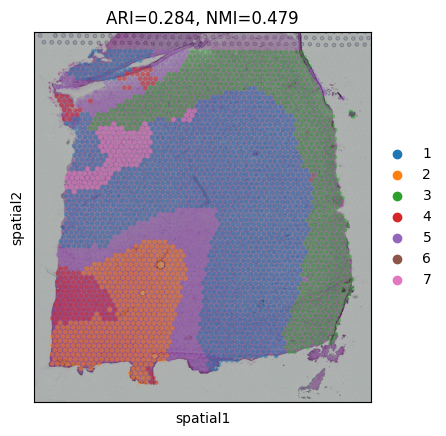

In [63]:
sc.pl.spatial(adata, color='3d-OT', img_key='hires',title='ARI=0.284, NMI=0.479', alpha=0.5, size=1.3,save='scGPT6733d-OT.png')

In [92]:
adata1=sc.read_h5ad('/home/dbj/lib_3d_OT/revise/scGPT/mousebrain-embedding.h5ad')

In [93]:
adata2=sc.read_h5ad('/home/dbj/mouse/SpatialGlue/Mouse_Brain/adata_peaks_normalized.h5ad')
adata1.obs['truth']=adata2.obs['RNA_clusters']
adata2.obs['truth']=adata2.obs['ATAC_clusters']
adata1.var_names_make_unique()
adata2.var_names_make_unique()

In [94]:
sc.pp.highly_variable_genes(adata1, flavor="seurat_v3", n_top_genes=3000)
adata1 =  adata1[:, adata1.var['highly_variable']]
adata1.obsm['feat'] = pca(adata1, n_comps=50)

adata2 = adata2[adata1.obs_names].copy()
if 'X_lsi' not in adata2.obsm.keys():
    sc.pp.highly_variable_genes(adata2, flavor="seurat_v3", n_top_genes=3000)
    lsi(adata2, use_highly_variable=False, n_components=51)
adata2.obsm['feat'] = adata2.obsm['X_lsi'].copy()

In [95]:
set_seed(7)
graph1 = prepare_data(adata1, location="spatial", nb_neighbors=16).to(device)
graph2 = prepare_data(adata2, location="spatial", nb_neighbors=16).to(device)
input_dim = graph1.express.shape[-1]
hidden_dim=32
model = extractModel(input_dim,hidden_dim,n_heads=4, n_layers=3)
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
start_time = time.time()
best_model1 = train_graph_extractor(graph1,graph2, model ,optimizer, device,epochs=300)

In [96]:
with torch.no_grad(): 
    MODEL=extractModel(input_dim=input_dim,hidden_dim=hidden_dim)
    MODEL.to(device)
    MODEL.load_state_dict(best_model1)
    MODEL.eval()
    recon1, recon2,mixed_modal_features = MODEL(graph1, graph2)
    mixed_modal_features = mixed_modal_features.squeeze(0) 
    gene_expression_matrix = mixed_modal_features.cpu().detach().numpy()
adata1.obsm['3d-OT']=gene_expression_matrix

In [97]:
clustering(adata1, n_clusters=18,key='3d-OT', method='mclust',random=2024,n_comp=20)

Using 3d-OT representation for clustering...
fitting ...
  |======================================================================| 100%


In [98]:
adata1

AnnData object with n_obs × n_vars = 9196 × 3000
    obs: 'nCount_Spatial', 'nFeature_Spatial', 'nCount_SCT', 'nFeature_SCT', 'nCount_ATAC', 'nFeature_ATAC', 'nCount_peaks', 'nFeature_peaks', 'RNA_clusters', 'ATAC_clusters', 'truth', 'n_genes', 'mclust', '3d-OT'
    var: 'name', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg'
    obsm: 'X_pca', 'X_umap', 'spatial', 'feat', '3d-OT', 'emb_pca'

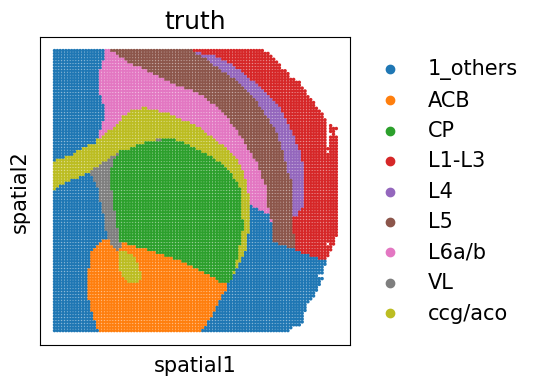

In [99]:
adata=sc.read_h5ad('/home/dbj/mouse/spatialglue_alldata/Dataset7_Mouse_Brain_ATAC/3d-OT.h5ad')
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (4,4)
plt.rcParams['font.size'] = 15

fig, ax = plt.subplots()
sc.pl.embedding(adata,basis='spatial',color='truth',size=25,ax=ax,save='truth.png')

In [100]:
import numpy as np
from sklearn.metrics import (homogeneity_score,mutual_info_score,v_measure_score,adjusted_mutual_info_score,normalized_mutual_info_score,adjusted_rand_score
)

true_labels = np.array(adata.obs['truth'])
cluster_labels = np.array(adata1.obs['3d-OT'])

homogeneity = homogeneity_score(true_labels, cluster_labels)
mutual_info = mutual_info_score(true_labels, cluster_labels)
v_measure = v_measure_score(true_labels, cluster_labels)
ami = adjusted_mutual_info_score(true_labels, cluster_labels)
nmi = normalized_mutual_info_score(true_labels, cluster_labels)
ari = adjusted_rand_score(true_labels, cluster_labels)

print("Homogeneity:", homogeneity)
print("Mutual Information:", mutual_info)
print("V-Measure:", v_measure)
print("AMI:", ami)
print("NMI:", nmi)
print("ARI:", ari)

Homogeneity: 0.46796041788269616
Mutual Information: 0.9349003210371717
V-Measure: 0.4030772064018328
AMI: 0.40114020538398776
NMI: 0.40307720640183287
ARI: 0.18820507937576164


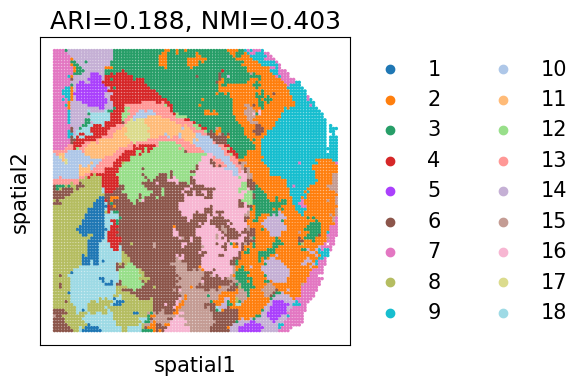

In [101]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (4,4)
plt.rcParams['font.size'] = 15

fig, ax = plt.subplots()
sc.pl.embedding(adata1,basis='spatial',color='3d-OT',title='ARI=0.188, NMI=0.403',size=25,ax=ax,save='scGPTmousebrain3d-OT.png')